# **Module 5 — LIFESTYLE COACH**
## MedAI Nexus | Habit Scoring + Gemini 1.5 Flash Wellness Planning
---
- **Model:** Gemini 1.5 Flash (Free API)
- **Task:** Score 6 lifestyle dimensions, visualizes them using a radar chart, and uses Gemini AI to generate a personalized 7-day wellness plan based on weak areas.
- **Goal:** User Health Data (All Modules Output) --> Context Builder --> Lifestyle Rule Engine + AI Suggestions --> Personalized Health Recommendation System

**Objective:** To provide personalized lifestyle recommendations based on the user’s health conditions, risk predictions, skin analysis, and medical report insights, using an intelligent rule-based + AI-driven system therey providing
- Diet plans
- Exercise routines
- Skincare advice
- Preventive health measures

## 1. Install & Import
---

In [18]:
!pip install google-generativeai -q

import os
import json
import math
import shutil
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import google.generativeai as genai
from google.colab import userdata

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Configure Gemini
---

In [19]:

GEMINI_API_KEY = userdata.get('Gemini_API_Key')
genai.configure(api_key=GEMINI_API_KEY)

print(" Gemini API configured.")
print("Model: gemini-1.5-flash")

 Gemini API configured.
Model: gemini-1.5-flash


## 3. Lifestyle Data Collection
---
In Streamlit this comes from form inputs.
Here we define the structure and create a sample for testing.

The 6 dimensions we measure:
1. **Sleep** — hours per night
2. **Activity** — exercise level and frequency
3. **Nutrition** — fruits, vegetables, water intake
4. **Habits** — smoking and alcohol
5. **Mental** — stress level
6. **Screen** — daily screen time


In [20]:
# Sample lifestyle data
#------------------------------

# Each field maps to one or more scoring formulas below

SAMPLE_LIFESTYLE = {
    # Sleep
    'sleep_hours'       : 6.5,      # hours per night (ideal: 7-9)

    # Activity
    'activity_level'    : 'Moderate',  # None / Light / Moderate / Intense
    'active_days_per_week': 3,          # 0-7

    # Nutrition
    'fruit_servings'    : 3,        # servings per day (target: 5)
    'veg_servings'      : 2,        # servings per day (target: 5)
    'water_litres'      : 2.0,      # litres per day (target: 2.5+)
    'diet_type'         : 'Mixed',  # Vegetarian / Vegan / Mixed / Carnivore

    # Habits
    'smoker'            : False,    # True / False
    'alcohol_units_per_week': 3,    # standard units

    # Mental
    'stress_level'      : 6,        # 1 (low) to 10 (high)
    'sleep_quality'     : 'Fair',   # Poor / Fair / Good / Excellent

    # Screen
    'screen_hours_per_day': 7,      # hours of non-work screen time
}

print("Sample lifestyle data defined:")
for k, v in SAMPLE_LIFESTYLE.items():
    print(f"  {k:<28}: {v}")

Sample lifestyle data defined:
  sleep_hours                 : 6.5
  activity_level              : Moderate
  active_days_per_week        : 3
  fruit_servings              : 3
  veg_servings                : 2
  water_litres                : 2.0
  diet_type                   : Mixed
  smoker                      : False
  alcohol_units_per_week      : 3
  stress_level                : 6
  sleep_quality               : Fair
  screen_hours_per_day        : 7


## 4. Scoring Engine — 6 Dimensions
---
Each dimension is scored from 0 to 100 using a mathematical formula.
The formulas are designed so that a healthy lifestyle gives 70-100
and an unhealthy one gives below 50.

This scoring is important because:
- It gives Gemini clear numbers to work with
- It shows the user exactly where they stand
- It identifies which areas need the most attention


In [21]:
def compute_lifestyle_scores(data: dict) -> dict:
    """
    Convert raw lifestyle inputs into 0-100 scores for 6 dimensions.

    Args:
        data : dict — the user's lifestyle form data

    Returns:
        dict — 6 dimension scores + overall score
    """
    scores = {}

    # ── 1. SLEEP SCORE ────────────────────────────────────────────────────────
    # Formula: 100 if between 7-9 hours (ideal range), else subtract 15 per hour off
    # Why 7-9? NHS and WHO guidelines for adults
    hours = data.get('sleep_hours', 7)
    if 7 <= hours <= 9:
        scores['Sleep'] = 100           # Perfect range
    else:
        # How many hours outside the range?
        deviation = abs(hours - 8)      # Distance from the midpoint (8 hours)
        scores['Sleep'] = max(0, 100 - deviation * 15)
        # max(0,...) ensures the score never goes negative

    # ── 2. ACTIVITY SCORE ─────────────────────────────────────────────────────
    # Two components: intensity level + how many days per week
    # Component 1: intensity (what kind of exercise)
    intensity_map = {
        'None'     : 0,
        'Light'    : 40,    # e.g. walking
        'Moderate' : 75,    # e.g. jogging, cycling
        'Intense'  : 100,   # e.g. gym, sports
    }
    intensity_score = intensity_map.get(data.get('activity_level', 'None'), 0)

    # Component 2: frequency (how many days per week out of 7)
    # Proportion of active days, then scale to 50 points
    days = data.get('active_days_per_week', 0)
    frequency_score = (days / 7) * 50  # 0 to 50 points

    # Combine: 50% from intensity, 50% from frequency
    scores['Activity'] = min(100, intensity_score * 0.5 + frequency_score)

    # ── 3. NUTRITION SCORE ────────────────────────────────────────────────────
    # Three sub-components: fruits, vegetables, water
    # Fruits: up to 5 servings per day (5 servings = full 20 points)
    fruit_pts = min(data.get('fruit_servings', 0), 5) * 4   # max 20 points

    # Vegetables: up to 5 servings per day (5 servings = full 20 points)
    veg_pts   = min(data.get('veg_servings', 0), 5) * 4     # max 20 points

    # Water: 2.5L = 40 points. Scaled linearly. Capped at 40 points.
    water_pts = min(data.get('water_litres', 0) * 16, 40)   # max 40 points

    # Diet bonus: vegetarian/vegan diets get a small bonus
    diet_bonus = {'Vegetarian': 10, 'Vegan': 15, 'Mixed': 5, 'Carnivore': 0}
    bonus = diet_bonus.get(data.get('diet_type', 'Mixed'), 5)

    scores['Nutrition'] = min(100, fruit_pts + veg_pts + water_pts + bonus)

    # ── 4. HABITS SCORE ───────────────────────────────────────────────────────
    # Start at 100, subtract penalties for smoking and alcohol
    habit_score = 100

    # Smoking: -40 points (major health risk)
    if data.get('smoker', False):
        habit_score -= 40

    # Alcohol: each unit per week costs 3 points, max penalty is -40
    alcohol_penalty = min(data.get('alcohol_units_per_week', 0) * 3, 40)
    habit_score -= alcohol_penalty

    scores['Habits'] = max(0, habit_score)  # Never below 0

    # ── 5. MENTAL SCORE ───────────────────────────────────────────────────────
    # Stress scale is 1-10 where 10 = most stressed
    # Convert so that stress 1 = 100 points, stress 10 = 0 points
    stress = data.get('stress_level', 5)
    scores['Mental'] = max(0, 100 - (stress - 1) * 11)
    # (stress-1) so that stress=1 gives 0 subtraction = 100 points
    # × 11 so that stress=10 gives 99 subtracted = 1 ≈ 0 points

    # Sleep quality bonus (adds up to 10 points for good mental score)
    quality_bonus = {'Poor': 0, 'Fair': 3, 'Good': 7, 'Excellent': 10}
    scores['Mental'] = min(100, scores['Mental'] + quality_bonus.get(
        data.get('sleep_quality', 'Fair'), 3))

    # ── 6. SCREEN SCORE ───────────────────────────────────────────────────────
    # Up to 4 hours is acceptable (work/study screens excluded)
    # Every hour above 4 costs 12 points
    screen = data.get('screen_hours_per_day', 0)
    excess = max(0, screen - 4)           # How many hours above the 4-hour limit
    scores['Screen'] = max(0, 100 - excess * 12)

    # ── OVERALL SCORE ─────────────────────────────────────────────────────────
    # Simple average of all 6 dimensions
    scores['Overall'] = round(sum(v for k, v in scores.items()) / 6, 1)

    return scores


# ── TEST IT ───────────────────────────────────────────────────────────

scores = compute_lifestyle_scores(SAMPLE_LIFESTYLE)   # ⭐ ADD THIS LINE


def get_health_status(score):
    if score >= 70:
        return "Good", "🟢"
    elif score >= 50:
        return "Moderate", "🟡"
    else:
        return "Poor", "🔴"


print("── Lifestyle Scores ────────────────────────────────────")

for dimension, score in scores.items():
    bar = '█' * int(score / 10)

    status, icon = get_health_status(score)

    print(f"  {dimension:<12}: {score:5.1f}  {bar:<10}  {icon} {status}")


# ── Overall Status ─────────────────────────

overall_status, _ = get_health_status(scores['Overall'])   # ⭐ FIX HERE

print("\n🧠 Overall Health Status:", overall_status)

if overall_status == "Poor":
    print("⚠️ Immediate lifestyle changes recommended")
elif overall_status == "Moderate":
    print("⚡ Some improvements needed")
else:
    print("✅ You are maintaining a healthy lifestyle")

── Lifestyle Scores ────────────────────────────────────
  Sleep       :  77.5  ███████     🟢 Good
  Activity    :  58.9  █████       🟡 Moderate
  Nutrition   :  57.0  █████       🟡 Moderate
  Habits      :  91.0  █████████   🟢 Good
  Mental      :  48.0  ████        🔴 Poor
  Screen      :  64.0  ██████      🟡 Moderate
  Overall     :  66.1  ██████      🟡 Moderate

🧠 Overall Health Status: Moderate
⚡ Some improvements needed


## 5. Basic Recommendation Engine
---
Generate simple rule-based recommendations based on lifestyle scores.

In [22]:
def generate_basic_recommendations(scores, data):
    rec = {
        "Diet": [],
        "Exercise": [],
        "Preventive": []
    }

    if scores['Sleep'] < 70:
        rec["Preventive"].append("Improve sleep to 7–9 hours")

    if scores['Activity'] < 70:
        rec["Exercise"].append("Exercise at least 5 days/week")

    if scores['Nutrition'] < 70:
        rec["Diet"].append("Increase fruits & vegetables intake")

    if scores['Mental'] < 70:
        rec["Preventive"].append("Manage stress (meditation)")

    if scores['Screen'] < 70:
        rec["Preventive"].append("Reduce screen time")

    return rec

In [23]:
basic_rec = generate_basic_recommendations(scores, SAMPLE_LIFESTYLE)

print("\nBasic Recommendations:")
for k, v in basic_rec.items():
    if v:
        print(f"\n{k}:")
        for item in v:
            print("•", item)


Basic Recommendations:

Diet:
• Increase fruits & vegetables intake

Exercise:
• Exercise at least 5 days/week

Preventive:
• Manage stress (meditation)
• Reduce screen time


## 5. Visual Insights Radar Chart Visualisation
---
To enhance interpretability and provide a comprehensive view of the user's lifestyle health, the system generates a combined visual dashboard called **Visual Insights** consisting:
1. **Score Breakdown (Bar Chart):**  
Shows individual scores for each lifestyle dimension, helping identify strong and weak areas quickly.

2. **Overall Health Indicator (Health Meter):**  
Displays the overall lifestyle score with a status (Good/Moderate/Poor) for quick health assessment.

3. **Lifestyle Radar Analysis (Radar Chart):**  
Also called a spider chart visualizes all dimensions together to highlight balance, strengths, and areas needing improvement.



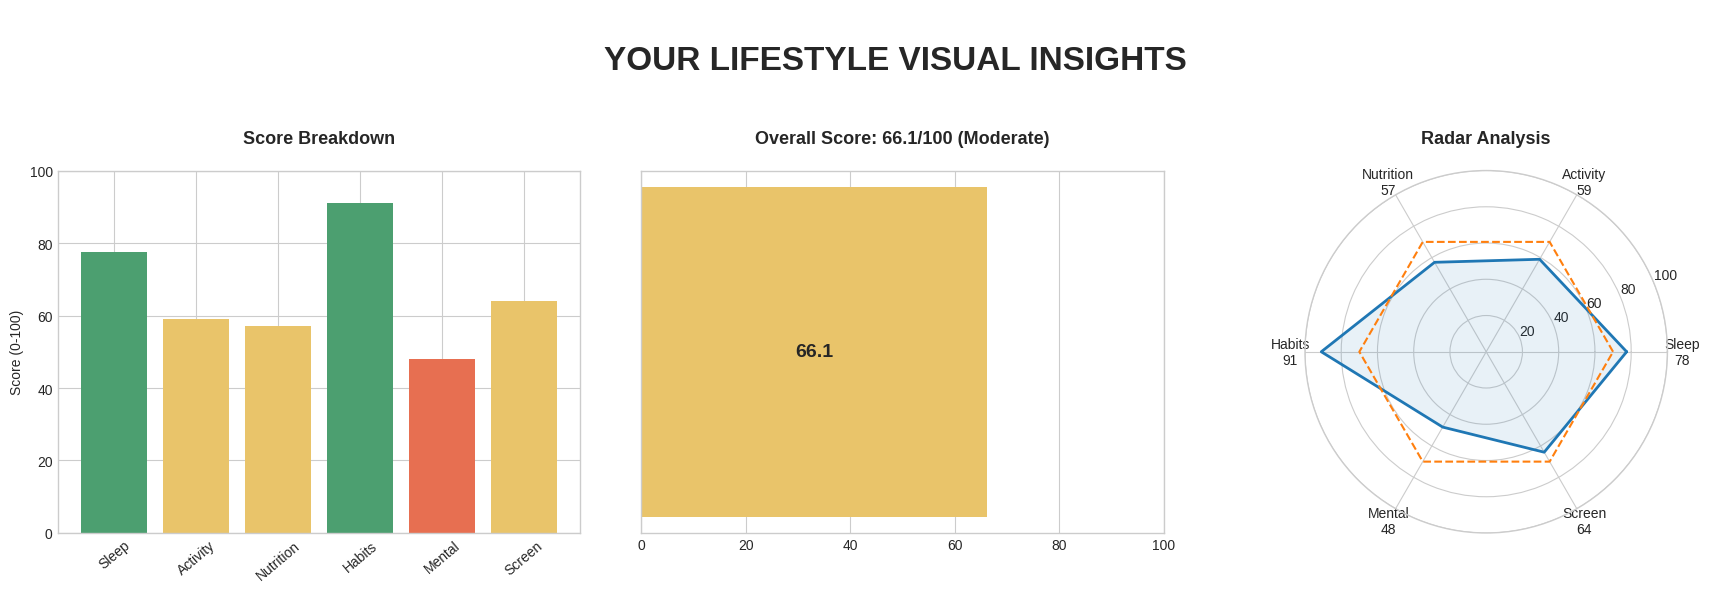

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_visual_insights(scores):

    labels = ['Sleep', 'Activity', 'Nutrition', 'Habits', 'Mental', 'Screen']
    values = [scores.get(k, 0) for k in labels]

    plt.style.use('seaborn-v0_8-whitegrid')

    fig = plt.figure(figsize=(18, 6))

    # ── STATUS FUNCTION ─────────────────────
    def get_health_status(score):
        if score >= 70:
            return "Good"
        elif score >= 50:
            return "Moderate"
        else:
            return "Poor"

    # ── COLOR FUNCTION ─────────────────────
    def get_color(score):
        if score >= 70: return '#4C9F70'   # muted green
        elif score >= 50: return '#E9C46A' # soft amber
        else: return '#E76F51'             # muted red'

    # ── 1. BAR CHART ───────────────────────
    ax1 = plt.subplot(1, 3, 1)

    colors = [get_color(v) for v in values]
    ax1.bar(labels, values, color=colors)

    ax1.set_title("Score Breakdown\n", fontsize=13, fontweight='bold')
    ax1.set_ylim(0, 100)
    ax1.set_ylabel("Score (0-100)")
    ax1.tick_params(axis='x', rotation=40)

    # ── 2. HEALTH METER ────────────────────
    ax2 = plt.subplot(1, 3, 2)

    overall = scores.get('Overall', 0)
    color = get_color(overall)
    status = get_health_status(overall)

    ax2.barh([""], [overall], color=color, height=0.25)
    ax2.set_xlim(0, 100)
    ax2.set_yticks([])

    # Center text inside bar
    ax2.text(overall/2, 0, f"{overall:.1f}",
             ha='center', va='center', fontsize=14, fontweight='bold')

    ax2.set_title(f"Overall Score: {overall:.1f}/100 ({status})\n",
                  fontsize=13, fontweight='bold')

    # ── 3. RADAR CHART ─────────────────────
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

    values_cycle = np.append(values, values[0])
    angles_cycle = np.append(angles, angles[0])

    ax3 = plt.subplot(1, 3, 3, polar=True)

    ax3.plot(angles_cycle, values_cycle, linewidth=2)
    ax3.fill(angles_cycle, values_cycle, alpha=0.1)

    # Target line
    target = [70] * (len(labels) + 1)
    ax3.plot(angles_cycle, target, linestyle='--', linewidth=1.5)

    # Labels
    ax3.set_thetagrids(
        angles * 180/np.pi,
        [f"{l}\n{scores.get(l, 0):.0f}" for l in labels]
    )

    ax3.set_ylim(0, 100)
    ax3.set_title("Radar Analysis\n", fontsize=13, fontweight='bold')

    # ── MAIN TITLE ─────────────────────────
    plt.suptitle("\nYOUR LIFESTYLE VISUAL INSIGHTS\n",
                 fontsize=24, fontweight='bold')

    plt.tight_layout()
    plt.show()


# ── CALL ─────────────────────────
plot_visual_insights(scores)

## 6. Gemini Wellness Plan Generation
---
We send the user's scores + health context to Gemini with a detailed system prompt.
Gemini returns a JSON-structured 7-day wellness plan.


In [33]:
WELLNESS_SYSTEM_PROMPT = """You are an expert wellness coach and nutritionist.
You create personalised, practical, motivating 7-day wellness improvement plans.

Your plans must:
1. Be SPECIFIC to the user's actual scores — address their lowest-scoring dimensions first
2. Be PRACTICAL — real actions, not vague advice ('Walk 20 minutes after lunch' not 'Exercise more')
3. Reference the user's health results if provided
4. Include variety — different activities/meals each day, not the same thing repeated
5. Be encouraging and positive in tone
6. ALWAYS include the disclaimer at the end

Return ONLY valid JSON with this exact structure:
{
  "health_score_summary": "2-3 sentences summarising current lifestyle based on scores",
  "priority_areas": ["list of 2-3 dimensions needing most improvement"],
  "weekly_plan": {
    "Monday":    {"morning": "...", "afternoon": "...", "evening": "..."},
    "Tuesday":   {"morning": "...", "afternoon": "...", "evening": "..."},
    "Wednesday": {"morning": "...", "afternoon": "...", "evening": "..."},
    "Thursday":  {"morning": "...", "afternoon": "...", "evening": "..."},
    "Friday":    {"morning": "...", "afternoon": "...", "evening": "..."},
    "Saturday":  {"morning": "...", "afternoon": "...", "evening": "..."},
    "Sunday":    {"morning": "...", "afternoon": "...", "evening": "..."}
  },
  "nutrition_tips": ["3-5 specific food/diet recommendations"],
  "mental_wellness_tips": ["3-5 stress/mindfulness suggestions"],
  "specific_recommendations": "personalised advice based on health module results",
  "motivational_message": "one encouraging closing message",
  "disclaimer": "This plan is for general wellness guidance only. Consult a healthcare professional before making significant changes to your diet or exercise routine."
}
"""


def generate_wellness_plan(lifestyle_data: dict, scores: dict, health_context: dict = None) -> dict:
    """
    Generate a personalised 7-day wellness plan using Gemini.

    Args:
        lifestyle_data : dict — raw user inputs
        scores         : dict — computed 0-100 scores per dimension
        health_context : dict — optional module 1/2/3 results

    Returns:
        dict — structured wellness plan ready for Streamlit display
    """

    import re

    # ── Build the user prompt ──────────────────────────────
    # We tell Gemini exactly what we know about this user
    prompt_parts = [
        WELLNESS_SYSTEM_PROMPT,
        "\n\nUSER LIFESTYLE SCORES (0-100):",
    ]

    # Add each score
    for dim, score in scores.items():
        if dim != 'Overall':
            status = 'NEEDS IMPROVEMENT' if score < 50 else 'FAIR' if score < 70 else 'GOOD'
            prompt_parts.append(f"  {dim}: {score:.0f}/100 — {status}")

    prompt_parts.append(f"  Overall Score: {scores.get('Overall', 0)}/100")

    # Add raw lifestyle data for context
    prompt_parts.append("\nUSER LIFESTYLE DETAILS:")
    for key, val in lifestyle_data.items():
        prompt_parts.append(f"  {key}: {val}")

    # Add health results from earlier modules if available
    if health_context:
        prompt_parts.append("\nHEALTH MODULE RESULTS (from earlier assessments):")
        for k, v in health_context.items():
            prompt_parts.append(f"  {k}: {v}")

    prompt_parts.append("\nReturn ONLY the JSON plan. No extra text before or after.")

    full_prompt = "\n".join(prompt_parts)

    # ── Call Gemini ──────────────────────────────
    model = genai.GenerativeModel(
        model_name       = "gemini-flash-latest",
        generation_config = genai.GenerationConfig(
            temperature  = 0.6,          # Slightly creative for varied wellness advice
            max_output_tokens = 3000,    # Wellness plans are longer than report explanations
        )
    )

    try:
        response = model.generate_content(full_prompt)
        result_text = response.text.strip()

        # ── Extract JSON ──────────────────────
        # Gemini sometimes wraps output in markdown code fences: ```json ... ```
        match = re.search(r'\{.*\}', result_text, re.DOTALL)
        if match:
            result_text = match.group()

        plan = json.loads(result_text)
    except json.JSONDecodeError as e:
        print(f"\n[ERROR] Gemini response could not be parsed as JSON: {e}")
        print(f"Raw response: {result_text[:500]}...")
        plan = {'parse_error': True,
                'raw_response': result_text,
                'health_score_summary': 'Could not generate a detailed plan due to an AI parsing error.',
                'priority_areas': ['General Wellness'],
                'weekly_plan': {},
                'nutrition_tips': ['Focus on whole, unprocessed foods.', 'Stay hydrated.'],
                'mental_wellness_tips': ['Practice mindfulness.', 'Ensure adequate rest.'],
                'specific_recommendations': 'Please consult with a healthcare professional.',
                'motivational_message': 'Every step counts!',
                'disclaimer': 'This plan is for general wellness guidance only. Consult a healthcare professional before making significant changes to your diet or exercise routine.'
               }

    except Exception as e:
        print(f"\n[ERROR] An unexpected error occurred during Gemini call: {e}")
        plan = {'parse_error': True,
                'raw_response': str(e),
                'health_score_summary': 'An unexpected error prevented plan generation.',
                'priority_areas': ['General Wellness'],
                'weekly_plan': {},
                'nutrition_tips': ['Focus on whole, unprocessed foods.', 'Stay hydrated.'],
                'mental_wellness_tips': ['Practice mindfulness.', 'Ensure adequate rest.'],
                'specific_recommendations': 'Please consult with a healthcare professional.',
                'motivational_message': 'Stay positive!',
                'disclaimer': 'This plan is for general wellness guidance only. Consult a healthcare professional before making significant changes to your diet or exercise routine.'
               }

    # The original if check is now obsolete as 'parse_error' is set in the except block
    # If the plan was successfully parsed, 'parse_error' will not be in it

    return plan


print("Wellness plan generator defined.")
print("Key: temperature=0.6 for variety, max_output_tokens=3000 for full 7-day plan.")

Wellness plan generator defined.
Key: temperature=0.6 for variety, max_output_tokens=3000 for full 7-day plan.


## 7. Display the Wellness Plan
---

In [34]:
def display_wellness_plan(plan: dict):
    """Print the wellness plan in a readable format."""

    if plan.get('parse_error'):
        print("[ERROR] Could not parse Gemini response.")
        print(plan.get('raw_response', '')[:500])
        return

    print("\n" + "="*65)
    print("  YOUR PERSONALISED 7-DAY WELLNESS PLAN")
    print("="*65)

    print(f"\nSUMMARY:\n{plan.get('health_score_summary', 'N/A')}")

    priority = plan.get('priority_areas', [])
    if priority:
        print(f"\nFOCUS AREAS: {', '.join(priority)}")

    # Print each day
    weekly = plan.get('weekly_plan', {})
    for day, activities in weekly.items():
        print(f"\n{day.upper()}:")
        print(f"  Morning   : {activities.get('morning', 'N/A')}")
        print(f"  Afternoon : {activities.get('afternoon', 'N/A')}")
        print(f"  Evening   : {activities.get('evening', 'N/A')}")

    # Nutrition tips
    nutrition = plan.get('nutrition_tips', [])
    if nutrition:
        print("\nNUTRITION TIPS:")
        for tip in nutrition:
            print(f"  - {tip}")

    # Mental wellness
    mental = plan.get('mental_wellness_tips', [])
    if mental:
        print("\nMENTAL WELLNESS TIPS:")
        for tip in mental:
            print(f"  - {tip}")

    if plan.get('specific_recommendations'):
        print(f"\nPERSONALISED ADVICE:\n  {plan['specific_recommendations']}")

    if plan.get('motivational_message'):
        print(f"\nMOTIVATION:\n  {plan['motivational_message']}")

    print(f"\nDISCLAIMER: {plan.get('disclaimer', '')}")
    print("="*65)

In [35]:
# Generate and display the plan
print("Generating your 7-day wellness plan...")
print("(This may take 10-20 seconds — Gemini is writing a full plan)")
print()

# Optional: pass health context from earlier modules
sample_health_context = {
    'skin_result'  : 'Eczema Photos (78.4% confidence)',
    'risk_result'  : 'Moderate diabetes risk (48.2%)',
    'report_result': 'HbA1c slightly elevated at 6.1%'
}

plan = generate_wellness_plan(
    lifestyle_data = SAMPLE_LIFESTYLE,
    scores         = scores,
    health_context = sample_health_context
)

display_wellness_plan(plan)

Generating your 7-day wellness plan...
(This may take 10-20 seconds — Gemini is writing a full plan)


  YOUR PERSONALISED 7-DAY WELLNESS PLAN

SUMMARY:
Your lifestyle shows strong consistency in habits and a solid sleep foundation, though your overall score is impacted by high stress and lower mental wellness scores. While your activity level is moderate, your nutrition and mental health require focused attention, especially given your slightly elevated HbA1c and eczema results.

FOCUS AREAS: Mental Wellness & Stress Management, Blood Sugar Regulation (Nutrition), Physical Activity Consistency

MONDAY:
  Morning   : Start with 5 minutes of guided box-breathing to lower cortisol; breakfast of steel-cut oats with cinnamon and flaxseeds to stabilize blood sugar.
  Afternoon : Take a 15-minute brisk walk immediately after lunch to help your body process glucose and clear your mind.
  Evening   : Apply a thick, fragrance-free emollient to skin after a lukewarm shower; read a physical book 

## 8. Save Plan
---

In [36]:

# Save plan
with open('wellness_plan.json', 'w') as f:
    json.dump({
        'lifestyle_inputs' : SAMPLE_LIFESTYLE,
        'scores'           : scores,
        'plan'             : plan,
    }, f, indent=2)

drive_dir = '/content/drive/MyDrive/medai_lifestyle/'
os.makedirs(drive_dir, exist_ok=True)
shutil.copy('wellness_plan.json', drive_dir)

print("Plan saved.")
print(f"Copied to Drive: {drive_dir}")

Plan saved.
Copied to Drive: /content/drive/MyDrive/medai_lifestyle/


## 9. Inference Function for Streamlit
---
In Streamlit, Module 5 has three main components:
1. A form for lifestyle inputs
2. A radar chart showing scores
3. A structured display of the 7-day plan


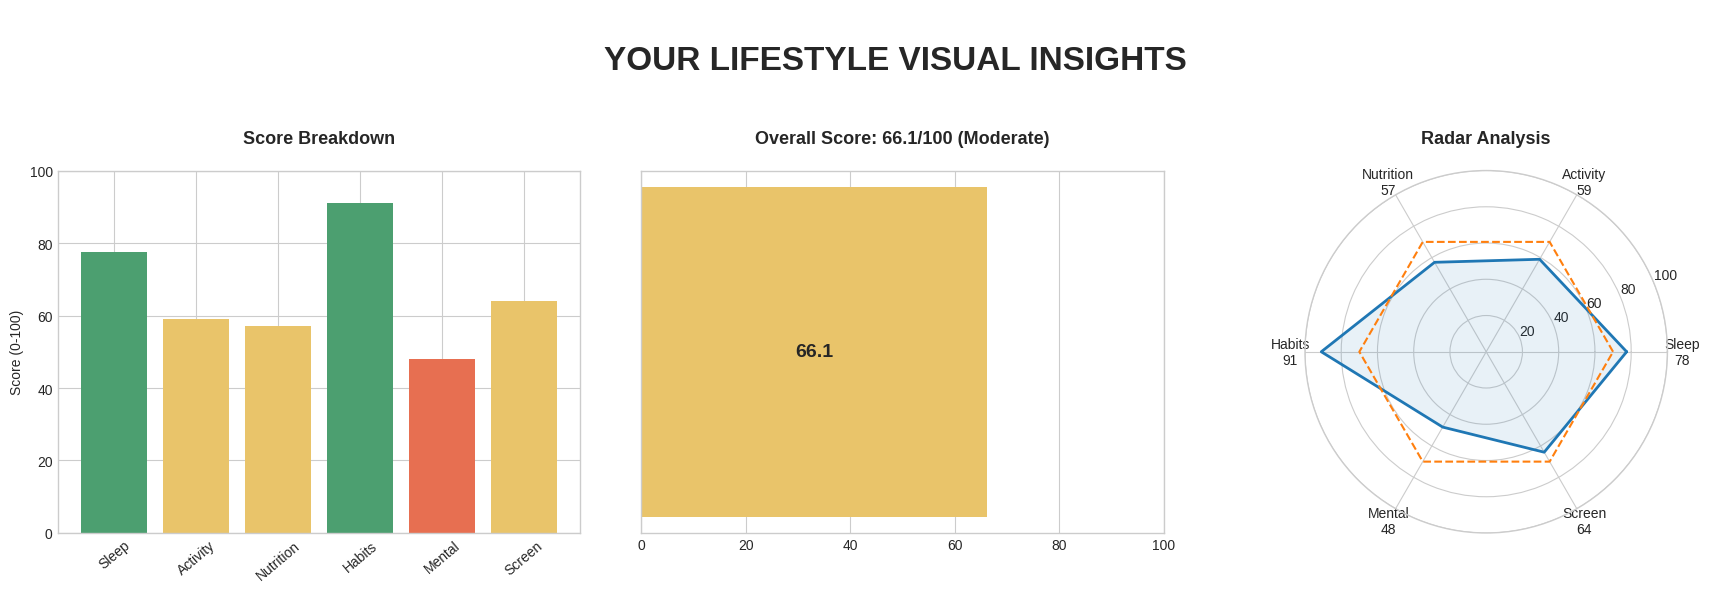

Overall score : 66.1
Plan valid    : True


In [37]:
def predict_lifestyle_plan(lifestyle_form_data: dict, health_context: dict = None) -> dict:
    """
    Complete inference function for Streamlit deployment.

    Args:
        lifestyle_form_data : dict — from st.form() inputs
        health_context      : dict — from st.session_state (module 1/2/3 results)

    Returns:
        dict — {scores: ..., plan: ..., radar_saved: bool}
    """
    # 1. Compute scores
    scores = compute_lifestyle_scores(lifestyle_form_data)

    # 2. Generate visual insights (including radar chart)
    plot_visual_insights(scores) # This function saves the radar chart internally

    # 3. Generate Gemini plan
    plan = generate_wellness_plan(lifestyle_form_data, scores, health_context)

    return {
        'scores'      : scores,
        'plan'        : plan,
        'radar_saved' : True,   # The plot_visual_insights function saves 'lifestyle_visual_insights.png'
    }


# Quick test
test_result = predict_lifestyle_plan(SAMPLE_LIFESTYLE, sample_health_context)
print(f"Overall score : {test_result['scores']['Overall']}")
print(f"Plan valid    : {'parse_error' not in test_result['plan']}")